In [1]:
#import libraries
import pandas as pd
import numpy as np

In [2]:
df = pd.read_csv('sms-spam-data.csv', encoding='latin-1')
df.head()

,v1,v2,Unnamed: 2,Unnamed: 3,Unnamed: 4
0,ham,"Go until jurong point, crazy.. Available only ...",NaN,NaN,NaN
1,ham,Ok lar... Joking wif u oni...,NaN,NaN,NaN
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...,NaN,NaN,NaN
3,ham,U dun say so early hor... U c already then say...,NaN,NaN,NaN
4,ham,"Nah I don't think he goes to usf, he lives aro...",NaN,NaN,NaN


In [3]:
df.shape

(5572, 5)

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5572 entries, 0 to 5571
Data columns (total 5 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   v1          5572 non-null   object
 1   v2          5572 non-null   object
 2   Unnamed: 2  50 non-null     object
 3   Unnamed: 3  12 non-null     object
 4   Unnamed: 4  6 non-null      object
dtypes: object(5)
memory usage: 217.8+ KB


In [5]:
df.isnull().sum()

v1               0
v2               0
Unnamed: 2    5522
Unnamed: 3    5560
Unnamed: 4    5566
dtype: int64

## 1. DATA CLEANING


In [6]:
#drop unnecessary columns
df.drop(columns=['Unnamed: 2','Unnamed: 3','Unnamed: 4'], inplace=True)
df.head()

,v1,v2
0,ham,"Go until jurong point, crazy.. Available only ..."
1,ham,Ok lar... Joking wif u oni...
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...
3,ham,U dun say so early hor... U c already then say...
4,ham,"Nah I don't think he goes to usf, he lives aro..."


In [7]:
#renaming columns
df.rename(columns={'v1':'label','v2':'message'}, inplace=True)
df.head()


,label,message
0,ham,"Go until jurong point, crazy.. Available only ..."
1,ham,Ok lar... Joking wif u oni...
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...
3,ham,U dun say so early hor... U c already then say...
4,ham,"Nah I don't think he goes to usf, he lives aro..."


In [8]:
df['label'] = df['label'].map({'ham':0, 'spam':1})
df.head()

,label,message
0,0,"Go until jurong point, crazy.. Available only ..."
1,0,Ok lar... Joking wif u oni...
2,1,Free entry in 2 a wkly comp to win FA Cup fina...
3,0,U dun say so early hor... U c already then say...
4,0,"Nah I don't think he goes to usf, he lives aro..."


In [9]:
# missing values
df.isnull().sum()

label      0
message    0
dtype: int64

In [10]:
# duplicate values
df.duplicated().sum()

np.int64(403)

In [11]:
# drop duplicates
df.drop_duplicates(keep='first', inplace=True)


In [12]:
df.duplicated().sum()

np.int64(0)

In [13]:
df.shape

(5169, 2)

## 2. EDA

In [14]:
df['label'].value_counts()

label
0    4516
1     653
Name: count, dtype: int64

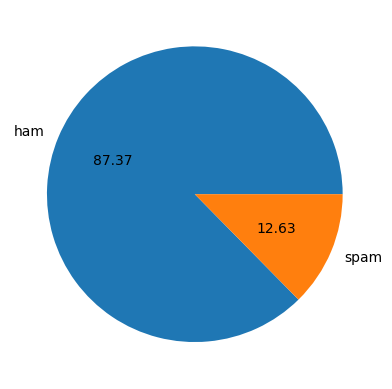

In [15]:
import matplotlib.pyplot as plt
plt.pie(df['label'].value_counts(), labels=['ham', 'spam'], autopct='%0.2f')
plt.show()

In [16]:
df['num_char'] = df['message'].apply(len)
df.head()

,label,message,num_char
0,0,"Go until jurong point, crazy.. Available only ...",111
1,0,Ok lar... Joking wif u oni...,29
2,1,Free entry in 2 a wkly comp to win FA Cup fina...,155
3,0,U dun say so early hor... U c already then say...,49
4,0,"Nah I don't think he goes to usf, he lives aro...",61


In [17]:
df['num_word'] = df['message'].apply(lambda x:len(x.split()))
df.head()

,label,message,num_char,num_word
0,0,"Go until jurong point, crazy.. Available only ...",111,20
1,0,Ok lar... Joking wif u oni...,29,6
2,1,Free entry in 2 a wkly comp to win FA Cup fina...,155,28
3,0,U dun say so early hor... U c already then say...,49,11
4,0,"Nah I don't think he goes to usf, he lives aro...",61,13


In [18]:
#ham messages
df[df['label'] == 0][['num_char', 'num_word']].describe()

,num_char,num_word
count,4516.000000,4516.000000
mean,70.459256,14.134632
std,56.358207,11.116240
min,2.000000,1.000000
25%,34.000000,7.000000
50%,52.000000,11.000000
75%,90.000000,18.000000
max,910.000000,171.000000


In [19]:
#spam messages
df[df['label'] == 1][['num_char', 'num_word']].describe()

,num_char,num_word
count,653.000000,653.000000
mean,137.891271,23.681470
std,30.137753,5.967672
min,13.000000,2.000000
25%,132.000000,22.000000
50%,149.000000,25.000000
75%,157.000000,28.000000
max,224.000000,35.000000


In [20]:
import seaborn as sns

<Axes: xlabel='num_word', ylabel='Count'>

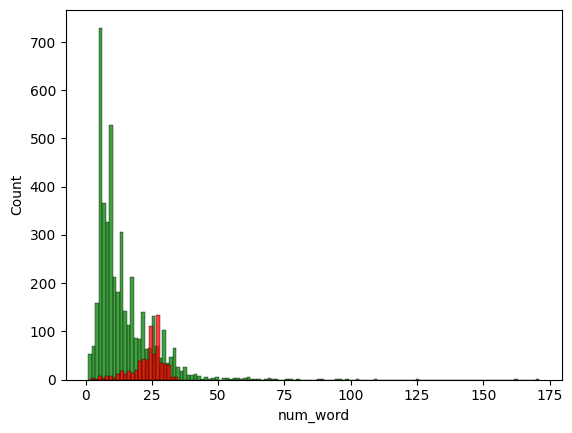

In [21]:
sns.histplot(df[df['label'] == 0]['num_word'], color='green')
sns.histplot(df[df['label'] == 1]['num_word'], color='red')

###  EDA Observations
- Dataset is imbalanced (more ham messages)
- Spam messages are longer
- Length can be a useful feature


## 3. DATA PREPROCESSING

In [22]:
import nltk

In [23]:
nltk.download('punkt')
nltk.download('stopwords')


[nltk_data] Downloading package punkt to C:\Users\trggo/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\trggo/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


True

In [24]:
from nltk.corpus import stopwords
import string

In [25]:
# function for

def transform_text(text):
    text = text.lower()
    text = nltk.word_tokenize(text)
    x = []
    for i in text:
        if i.isalnum() and i not in stopwords.words('english') and i not in string.punctuation:
            x.append(ps.stem(i))
    return " ".join(x)

In [26]:
from nltk.stem.porter import PorterStemmer
ps = PorterStemmer()


In [28]:
df['transformed_msg'] = df['message'].apply(transform_text)
df.head()

,label,message,num_char,num_word,transformed_msg
0,0,"Go until jurong point, crazy.. Available only ...",111,20,go jurong point crazi avail bugi n great world...
1,0,Ok lar... Joking wif u oni...,29,6,ok lar joke wif u oni
2,1,Free entry in 2 a wkly comp to win FA Cup fina...,155,28,free entri 2 wkli comp win fa cup final tkt 21...
3,0,U dun say so early hor... U c already then say...,49,11,u dun say earli hor u c alreadi say
4,0,"Nah I don't think he goes to usf, he lives aro...",61,13,nah think goe usf live around though


## 4. MODEL BUILDING

In [120]:
from sklearn.feature_extraction.text import TfidfVectorizer
tfidf = TfidfVectorizer(max_features=3000)

In [121]:
x = tfidf.fit_transform(df['transformed_msg'])

In [122]:
x.shape

(5169, 3000)

In [123]:
y = df['label'].values

In [124]:
y

array([0, 0, 1, ..., 0, 0, 0], shape=(5169,))

In [125]:
from sklearn.model_selection import train_test_split

In [126]:
x_train, x_test, y_train, y_test = train_test_split(x,y, test_size=0.2, random_state=42, stratify=y)

In [127]:
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import accuracy_score, precision_score, recall_score, confusion_matrix

In [128]:
model = MultinomialNB()
model.fit(x_train, y_train)
y_pred = model.predict(x_test)


In [129]:
print("Accuracy score: ",accuracy_score(y_test, y_pred))
print("Precision score: ",precision_score(y_test, y_pred))
print("Recall score: ",recall_score(y_test, y_pred))


Accuracy score:  0.9748549323017408
Precision score:  0.981651376146789
Recall score:  0.816793893129771


Text(0.5, 1.0, 'Confusion Matrix')

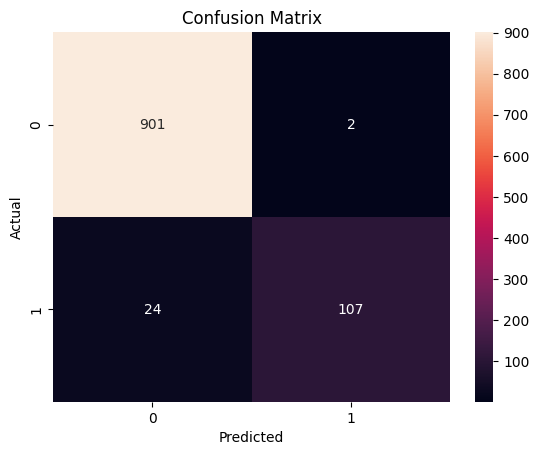

In [130]:
cm = confusion_matrix(y_test, y_pred)

sns.heatmap(cm, annot=True, fmt='d')
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")

In [113]:
from sklearn.linear_model import LogisticRegression

In [117]:
LR_model = LogisticRegression(max_iter=1000, class_weight='balanced')
LR_model.fit(x_train, y_train)
y_pred1 = LR_model.predict(x_test)

In [118]:
print("Accuracy: ", accuracy_score(y_test, y_pred1))
print("Precision: ", precision_score(y_test, y_pred1))
print("Recall: ", recall_score(y_test, y_pred1))

Accuracy:  0.9738878143133463
Precision:  0.8939393939393939
Recall:  0.9007633587786259


Naive Bayes Model is selected because of higher precision

In [131]:
import pickle

pickle.dump(tfidf, open('tfidf.pkl', 'wb'))
pickle.dump(model, open('model.pkl', 'wb'))